# Rigid bodies and joints with Create functions

Notebook `python/Notebooks/tutorialRigidBodyCreate.ipynb` - the same model built from nodes, objects and markers is
`python/Notebooks/tutorialRigidBody.ipynb`.

This tutorial sets up a multibody system of a ground, two rigid bodies and two revolute joints, driven by gravity:
a double pendulum in 3D. The `mbs.Create...` functions add a body or a joint with everything it needs in one call;
the outputs below each cell are those of the last run.

We import the Exudyn library, the inertia class of a cuboid and the sensor class; `exudyn.graphics` makes the
graphics of the bodies. Many examples use the star import `from exudyn.utilities import *` instead, which is handy
for rapid model development.

In [1]:
import exudyn as exu
from exudyn.utilities import InertiaCuboid, SensorBody, RotationMatrixX, RotationMatrixY
from exudyn.interactive import ShowImage
import exudyn.graphics as graphics
import numpy as np

SC = exu.SystemContainer()
mbs = SC.AddSystem()

Some geometrical parameters, and a ground body - a checkerboard below the pendulum, for the images. The ground is at
$[0,0,0]$; there could be several ground objects.

In [2]:
g = [0,-9.81,0]     #gravity
L = 1               #length
w = 0.1             #width
bodyDim = [L,w,w]   #body dimensions
pMid0 = np.array([L*0.5,0,0]) #center of body0

oGround = mbs.CreateGround(referencePosition=[0,0,0],
                           graphicsDataList=[graphics.CheckerBoard(point=[0.5,-1.6,0], normal=[0,1,0], size=3)])

For the physical parameters of a rigid body we use the class `RigidBodyInertia`: mass, center of mass (COM) and
inertia, which can be shifted or added; derived classes give the inertias of cylinders, cuboids, etc. The center of
mass of the first link is moved axially - it would be at the body's local position $[0,0,0]$ otherwise.

For visualization, the body is a brick, and a basis (three RGB vectors) is drawn at its center of mass.
`mbs.CreateRigidBody` adds the node, the body and the gravity load at once; it could also set initial velocities, and
`nodeType` selects the rotation parameters of the node, see [the node types](#sec-nodetype):
`RotationEulerParameters` (fast, one additional algebraic equation, needs an implicit solver), `RotationRxyz`
(singular if the second angle reaches $\pm 90°$, no algebraic equation) or `RotationRotationVector` (for Lie group
integrators, also explicit; the fewest unknowns). The reference frame of the body could also be given at once as
`referenceHT`, a homogeneous transformation `exu.HT`.

In [3]:
iCube0 = InertiaCuboid(density=5000, sideLengths=bodyDim)
iCube0 = iCube0.Translated([-0.25*L,0,0]) #transform COM, COM not at reference point!

graphicsBody0 = graphics.Brick(centerPoint=[0,0,0], size=[L,w,w], color=graphics.color.red)
graphicsCOM0 = graphics.Basis(origin=iCube0.com, length=2*w)

b0 = mbs.CreateRigidBody(inertia = iCube0, #includes COM
                         referencePosition = pMid0,
                         gravity = g,
                         graphicsDataList = [graphicsCOM0, graphicsBody0])

A revolute joint about the global $z$-axis attaches the first body to the ground. `CreateRevoluteJoint` attaches a
revolute joint immediately to rigid bodies, with the position and axis given once, in global coordinates (by
default) of the reference configuration; it computes the markers and their frames. The same joint built from markers
and a generic joint is in the other rigid body tutorial.

In [4]:
oJoint0 = mbs.CreateRevoluteJoint(itemNumbers=[oGround, b0], position=[0,0,0],
                                  axis=[0,0,1], axisRadius=0.2*w, axisLength=1.4*w)

The second link hangs at the end of the first and points along $z$; its graphics is a `RigidLink`, and its joint
turns about the global $x$-axis:

In [5]:
graphicsBody1 = graphics.RigidLink(p0=[0,0,-0.5*L], p1=[0,0,0.5*L],
                                   axis0=[1,0,0], axis1=[0,0,0], radius=[0.06,0.05],
                                   thickness=0.1, width=[0.12,0.12], color=graphics.color.lightgreen)

b1 = mbs.CreateRigidBody(inertia = InertiaCuboid(density=5000, sideLengths=[0.1,0.1,1]),
                         referencePosition = np.array([L,0,0.5*L]),
                         gravity = g,
                         graphicsDataList = [graphicsBody1])

oJoint1 = mbs.CreateRevoluteJoint(itemNumbers=[b0, b1], position=[L,0,0],
                                  axis=[1,0,0], axisRadius=0.2*w, axisLength=1.4*w)

Optionally, forces and torques on bodies - with `bodyFixed=True`, the direction would rotate with the body - and a
sensor for the position of the tip of the second link:

In [6]:
force = [0,0.5,0]       #0.5N   in y-direction
torque = [0.1,0,0]      #0.1Nm around x-axis
lForce = mbs.CreateForce(itemNumber=b1, loadVector=force, localPosition=[0,0,0.5], bodyFixed=False)
lTorque = mbs.CreateTorque(itemNumber=b1, loadVector=torque, bodyFixed=False)

sens1 = mbs.AddSensor(SensorBody(bodyNumber=b1, localPosition=[0,0,0.5*L], storeInternal=True,
                                 outputVariableType=exu.OutputVariableType.Position))

Before the simulation, `Assemble()` links objects, nodes, markers, ..., assigns the initial values and checks the
system. Then the system can be inspected - `print(mbs)` gives an overview, `mbs.systemData.Info()` every item as
dictionary.

In [7]:
mbs.Assemble()
print(mbs)

<systemData: 
  Number of nodes= 2
  Number of objects = 5
  Number of markers = 8
  Number of loads = 4
  Number of sensors = 1
  Number of ODE2 coordinates = 14
  Number of ODE1 coordinates = 0
  Number of AE coordinates   = 12
  Number of data coordinates   = 0

For details see mbs.systemData, mbs.sys and mbs.variables
>


There are 2 nodes for the two rigid bodies; the five objects are the ground, the 2 bodies and the 2 joints.

The degree of freedom of a constrained system is not always obvious, and constraints added by mistake may be
redundant, which a solver cannot handle. `ComputeSystemDegreeOfFreedom` shows both: the 14 coordinates of the two
Euler parameter nodes, $2\times 5$ joint constraints and 2 Euler parameter constraints give a degree of freedom of 2.
Two identical joints would show 5 redundant constraints.

In [8]:
dof = mbs.ComputeSystemDegreeOfFreedom(verbose=True)

ODE2 coordinates          = 14
total constraints         = 12
redundant constraints     = 0
pure algebraic constraints= 0
degree of freedom         = 2


`DrawSystemGraph` shows the structure of the model - which nodes, objects, markers, loads and sensors there are and
how they are connected. `CreateRigidBody` added an `ObjectRigidBody`, a `NodeRigidBodyEP`, a `LoadMassProportional`
for gravity with a `MarkerBodyMass`; `CreateRevoluteJoint` two `MarkerBodyRigid` and an `ObjectJointRevoluteZ`. It
needs the package networkx.

In [9]:
try:
    mbs.DrawSystemGraph(useItemTypes=True)
except ImportError:
    print('DrawSystemGraph needs networkx: pip install networkx')

DrawSystemGraph needs networkx: pip install networkx


The model in its reference configuration, without the nodes and the gravity loads, from a view turned so that the
three axes can be seen. In a script, `SC.renderer.Start()` opens the render window instead; there, many options of
the visualization settings help, see [the visualization settings](#sec-visualizationsettingsmain).

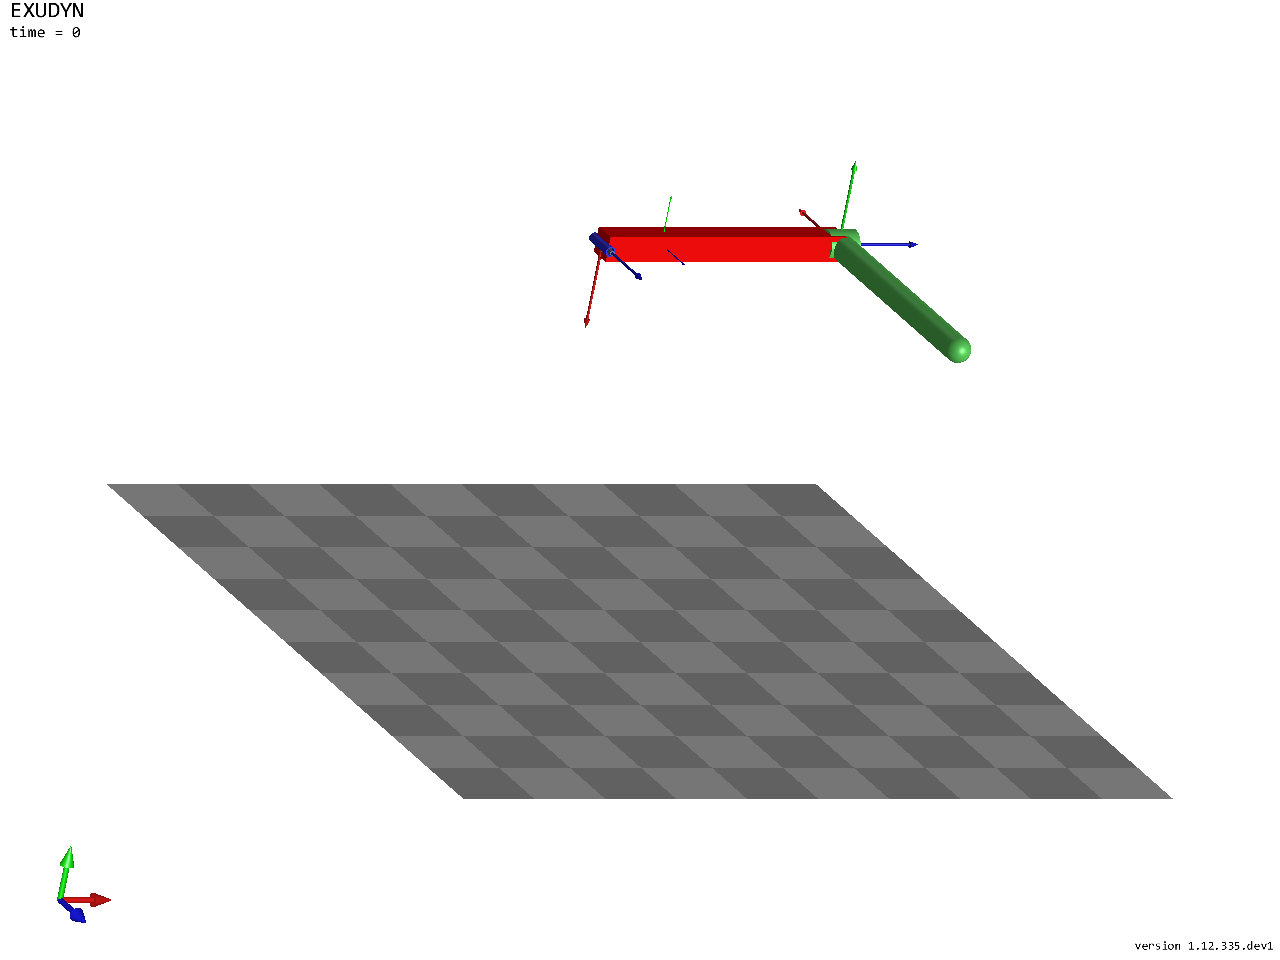

In [10]:
SC.visualizationSettings.nodes.show = False
SC.visualizationSettings.loads.show = False
SC.visualizationSettings.connectors.showJointAxes = True
SC.visualizationSettings.general.showSolverInformation = False
view = RotationMatrixX(-0.4) @ RotationMatrixY(-0.5)
image = ShowImage(SC, size=[1280,960], modelRotation=view)

The solver settings: implicit solvers have no automatic step size, so the end time and the step size are set. The
solution is stored every 5 ms for the `SolutionViewer`; `timeIntegration.realtime.active = True` would let a
simulation in a render window run in real time.

The **index 2** (velocity level) trapezoidal rule is energy conserving (guaranteed for linear systems, very often also
for nonlinear multibody systems), but leads to a small drift of the position constraints, linear in time. The default
**generalized-$\alpha$ method** (index 3) damps numerically, with its spectral radius, which stabilizes the
constraints; for fixed step sizes, it is the recommended integrator.

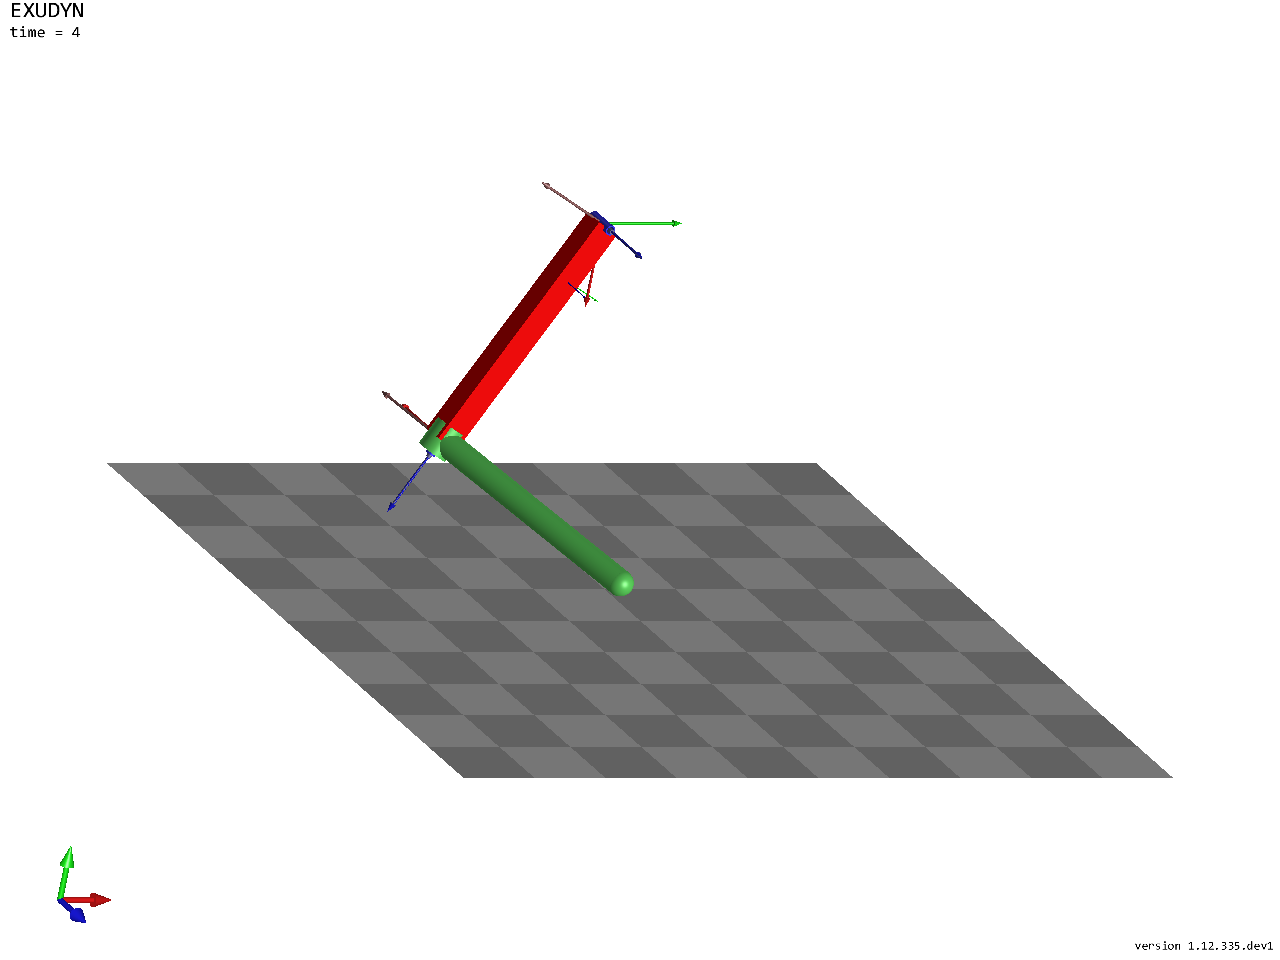

In [11]:
tEnd = 4 #simulation time
h = 1e-3 #step size
simulationSettings = exu.SimulationSettings()
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.writePeriod = 0.005 #store every 5 ms

mbs.SolveDynamic(simulationSettings = simulationSettings,
                 solverType = exu.DynamicSolverType.TrapezoidalIndex2)

image = ShowImage(SC, size=[1280,960], modelRotation=view) #the state at the end

The vertical position of the tip over time - `PlotSensor` has many options to show results:

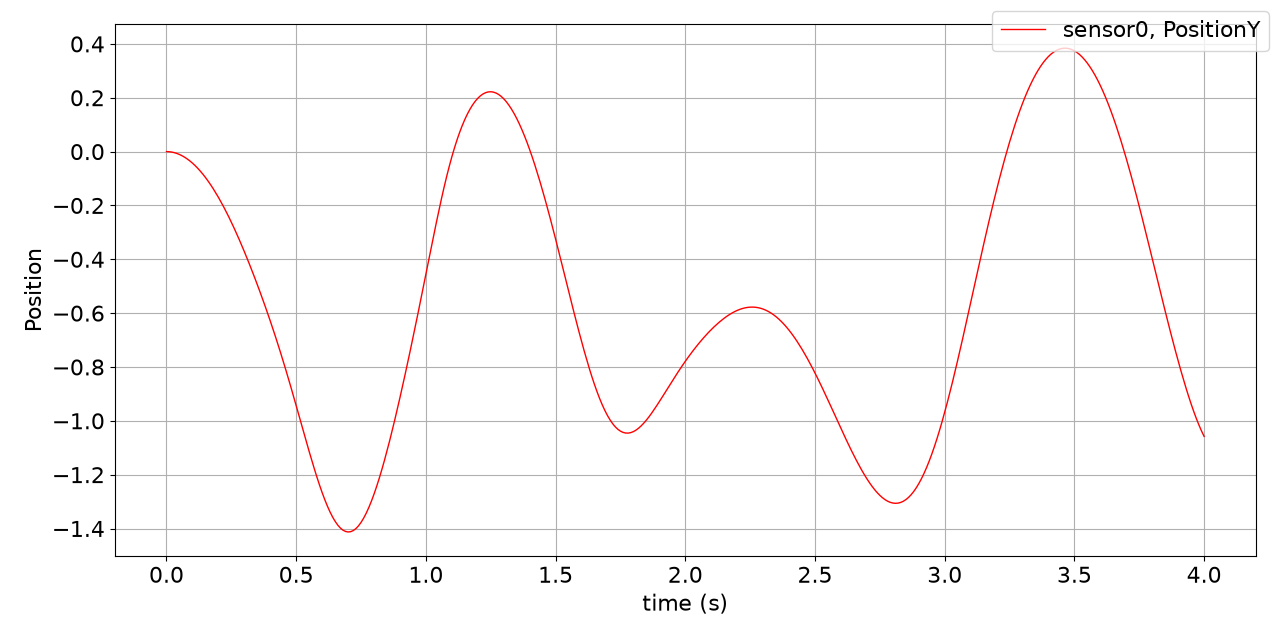

In [12]:
mbs.PlotSensor(sensorNumbers=[sens1], components=[1], closeAll=True)

The frame of the second body at the end, as homogeneous transformation `exu.HT`:

In [13]:
H = mbs.GetObjectOutputBody(b1, exu.OutputVariableType.HomogeneousTransformation, localPosition=[0,0,0])
print('position of body 1:', np.round(H.translation, 4))
print('rotation angle of body 1 (rad):', round(H.RotationAngle(), 4))

position of body 1: [-0.329  -0.9634  0.4621]
rotation angle of body 1 (rad): 2.1108


In a script, `mbs.SolutionViewer()` shows the stored motion forward and backward in the render window.
**Congratulations**, you can model multibody systems now. Much more is possible, including feedback control and
flexible bodies, see the examples.